# Task 4: Disease Prediction from Medical Data

## Breast Cancer Detection Using Machine Learning

### Objective
Predict the classification of breast tumor samples using structured medical data and machine learning classification algorithms.

### Approach
Apply classification techniques to the Breast Cancer dataset and compare multiple machine learning models.

### Algorithms Used
- Support Vector Machine (SVM)
- Logistic Regression
- Random Forest
- XGBoost

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
breast_cancer = load_breast_cancer()

X = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)

y = pd.Series(
    breast_cancer.target,
    name="Target"
)

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

Dataset Shape: (569, 30)
Target Shape: (569,)


In [3]:
print("Feature Names:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(breast_cancer.target_names)

print("\nDataset Information:")
print(X.info())

Feature Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target Classes:
['malignant' 'benign']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter       

In [4]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
print("Missing Values:")
print(X.isnull().sum().sum())

Missing Values:
0


Target
1    357
0    212
Name: count, dtype: int64


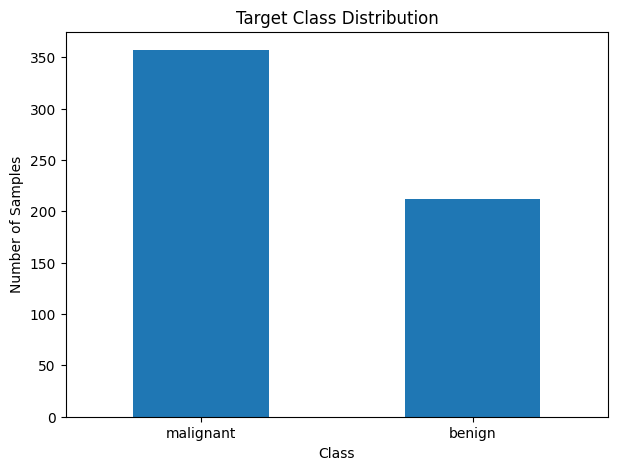

In [6]:
target_counts = y.value_counts()

print(target_counts)

target_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(
    [0, 1],
    breast_cancer.target_names,
    rotation=0
)

plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [9]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

In [10]:
lr_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [12]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [13]:
def evaluate_model(name, y_true, y_pred, y_prob):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }

In [14]:
results = []

results.append(
    evaluate_model(
        "SVM",
        y_test,
        svm_pred,
        svm_prob
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred,
        lr_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_prob
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM,0.982456,0.986111,0.986111,0.986111,0.995040
1,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
2,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993056
3,XGBoost,0.964912,0.959459,0.986111,0.972603,0.994378


In [15]:
print("SVM Classification Report")
print(
    classification_report(
        y_test,
        svm_pred,
        target_names=breast_cancer.target_names
    )
)

print("\nLogistic Regression Classification Report")
print(
    classification_report(
        y_test,
        lr_pred,
        target_names=breast_cancer.target_names
    )
)

print("\nRandom Forest Classification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=breast_cancer.target_names
    )
)

print("\nXGBoost Classification Report")
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=breast_cancer.target_names
    )
)

SVM Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Logistic Regression Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Random Forest Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.9

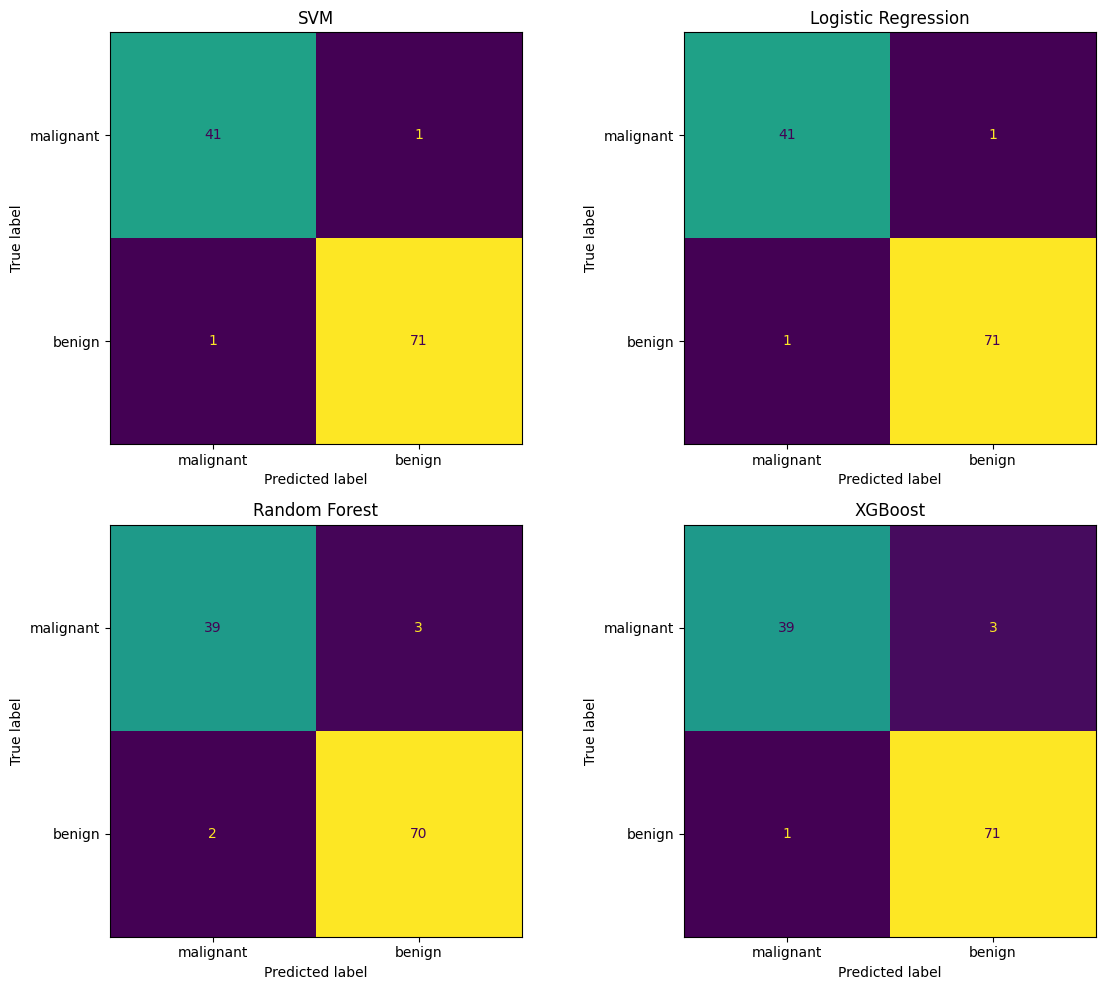

In [16]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

models = [
    ("SVM", y_test, svm_pred),
    ("Logistic Regression", y_test, lr_pred),
    ("Random Forest", y_test, rf_pred),
    ("XGBoost", y_test, xgb_pred)
]

for ax, (name, y_true, pred) in zip(
    axes.ravel(),
    models
):

    cm = confusion_matrix(y_true, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=breast_cancer.target_names
    )

    disp.plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

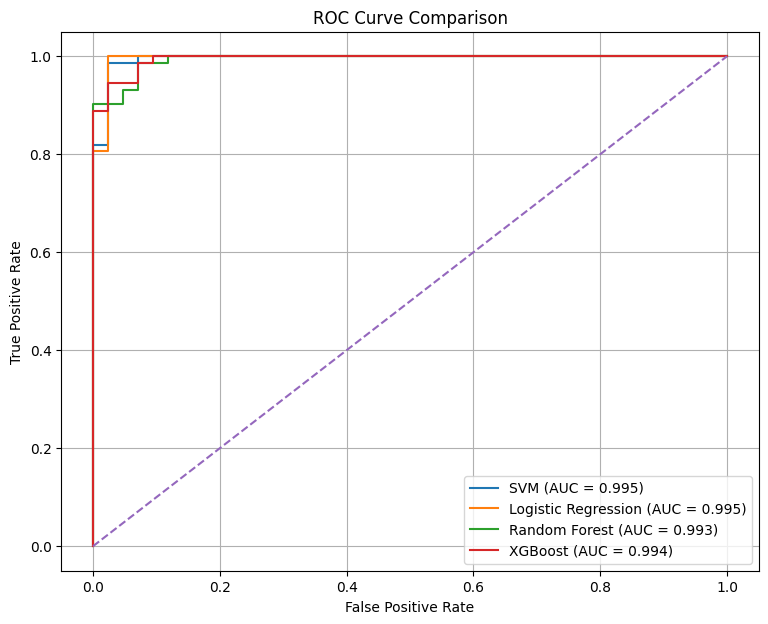

In [17]:
plt.figure(figsize=(9, 7))

models_probabilities = {
    "SVM": svm_prob,
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob
}

for name, probabilities in models_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


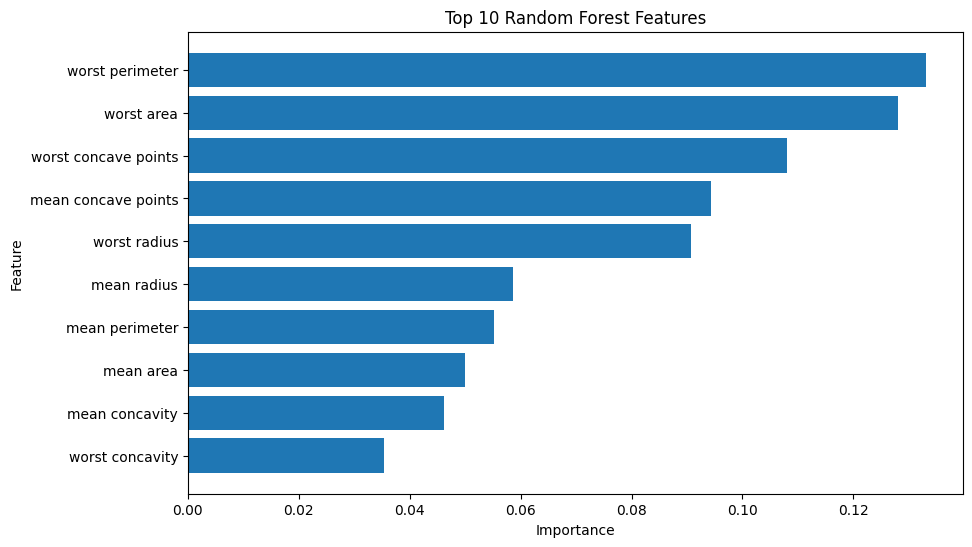

In [19]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")

plt.show()

In [20]:
results_df.to_csv(
    "breast_cancer_model_results.csv",
    index=False
)

feature_importance.to_csv(
    "breast_cancer_feature_importance.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


# Conclusion

This project implemented machine learning classification techniques for breast cancer dataset classification.

Four classification algorithms were evaluated:

- Support Vector Machine (SVM)
- Logistic Regression
- Random Forest
- XGBoost

The models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Confusion matrices and ROC curves were also used to analyze model performance.

Feature importance analysis was performed using Random Forest to examine the relative contribution of the input features.

The results demonstrate how different classification algorithms can be applied to structured medical datasets and compared using multiple evaluation metrics.

### Important Note

This project is developed for educational and machine learning experimentation purposes. The model is not intended to replace professional medical diagnosis or clinical decision-making.

# Project Summary

This project focuses on breast cancer classification using machine learning techniques on structured medical data.

The dataset contains 569 samples and 30 numerical features derived from breast cancer diagnostic measurements.

The workflow includes:

1. Dataset loading and exploration
2. Data quality and missing-value checking
3. Train-test splitting
4. Feature scaling
5. Training multiple classification models
6. Model evaluation using Accuracy, Precision, Recall, F1-Score, and ROC-AUC
7. Confusion matrix analysis
8. ROC curve comparison
9. Feature importance analysis
10. Saving model comparison and feature-importance results

The implemented models are:

- Support Vector Machine (SVM)
- Logistic Regression
- Random Forest
- XGBoost

This project is intended for educational and machine learning experimentation purposes and should not be used as a substitute for professional medical diagnosis.